In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Student_Placement_Career_Prediction_Dataset.csv")
df.head()

,student_id,age,gender,branch,cgpa,internship_count,project_count,certifications_count,coding_skills_score,communication_skills_score,soft_skills_score,hackathon_participation,placement_status
0,1,23,Male,IT,8.99,4,6,2,41,71,59,Yes,Placed
1,2,24,Female,Mechanical,8.36,4,7,5,42,64,97,No,Placed
2,3,22,Female,EEE,7.18,4,5,2,84,98,51,No,Placed
3,4,24,Female,Mechanical,6.28,0,2,4,60,100,92,No,Not Placed
4,5,24,Female,IT,5.30,3,4,1,78,61,77,No,Not Placed


In [26]:
df.isna().sum()

student_id                    0
age                           0
gender                        0
branch                        0
cgpa                          0
internship_count              0
project_count                 0
certifications_count          0
coding_skills_score           0
communication_skills_score    0
soft_skills_score             0
hackathon_participation       0
placement_status              0
dtype: int64

In [25]:
df.columns

Index(['student_id', 'age', 'gender', 'branch', 'cgpa', 'internship_count',
       'project_count', 'certifications_count', 'coding_skills_score',
       'communication_skills_score', 'soft_skills_score',
       'hackathon_participation', 'placement_status'],
      dtype='object')

In [3]:
# sns.pairplot(df, hue = 'Class');

In [9]:
# separate input and output
# check distribution of fake and original notes => countplot
# cross validation => 80 - 20 split
# build the model
# evaluate

In [4]:
x = df.drop('placement_status', axis = 1)
y = df['placement_status']

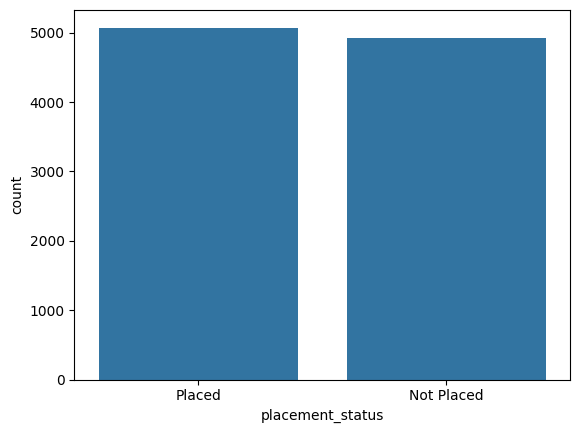

In [5]:
sns.countplot(x = y);

In [10]:
x = pd.get_dummies(x)

In [11]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state= 0,
                                                   test_size= 0.2)

In [12]:
x_train.shape, y_train.shape

((8000, 19), (8000,))

In [13]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state= 0)
dt.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [14]:
# eval

In [15]:
y_pred = dt.predict(x_test)

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report

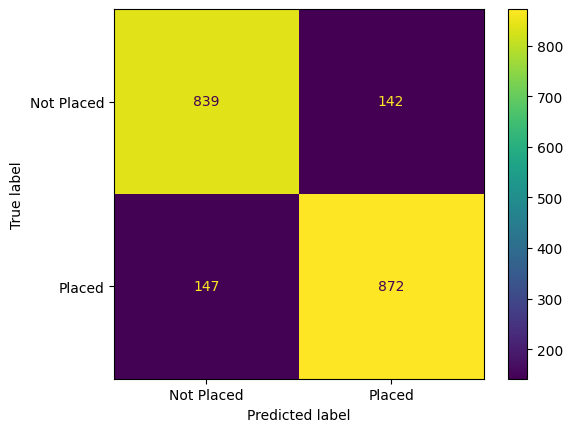

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       0.85      0.86      0.85       981
      Placed       0.86      0.86      0.86      1019

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



In [19]:
# feature importances

In [20]:
dt.feature_importances_

array([0.03258094, 0.00829327, 0.30983672, 0.15912382, 0.1267404 ,
       0.13945091, 0.07563298, 0.04805745, 0.04200339, 0.00196628,
       0.00116689, 0.00296869, 0.00276368, 0.0051446 , 0.00413143,
       0.00320209, 0.0026108 , 0.01041084, 0.02391483])

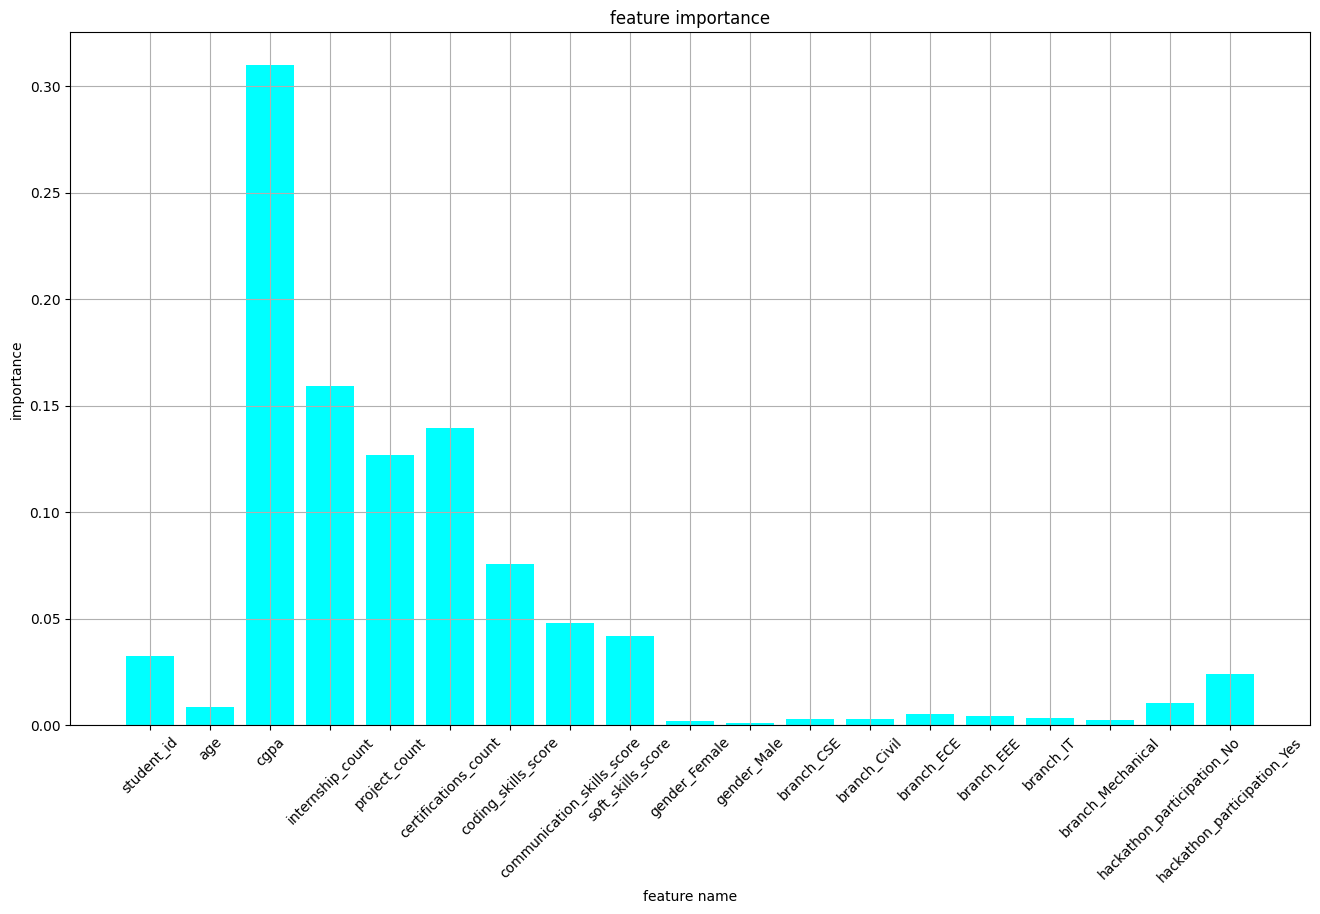

In [23]:
plt.figure(figsize=(16, 9))
plt.title("feature importance")
plt.xlabel("feature name")
plt.ylabel("importance")
plt.xticks(rotation = 45)
plt.bar(x.columns, dt.feature_importances_, color = 'cyan')
plt.grid();

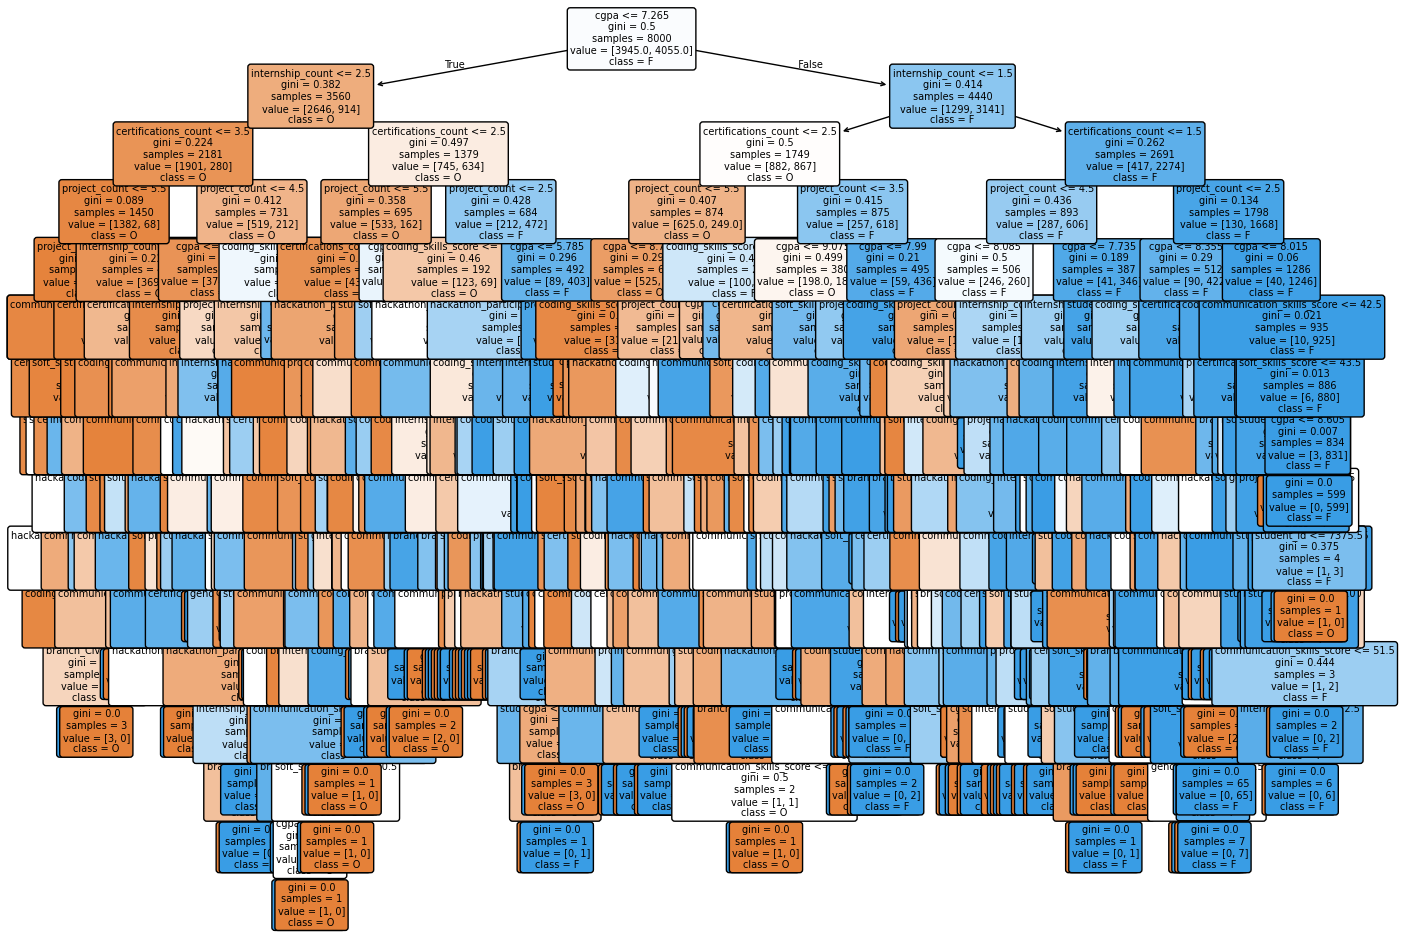

In [24]:
plt.figure(figsize=(16, 12))
from sklearn.tree import plot_tree

plot_tree(dt, filled= True, fontsize= 7, rounded= True,
         feature_names= x.columns, class_names= ['O', 'F']);